<a href="https://colab.research.google.com/github/akhtartameem39-cloud/Lab-work-8th-semester/blob/main/Week9_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/content/sample_data/california_housing_test.csv")  # change path

# Preview
print(df.head())

# Basic info
print(df.info())

# Summary statistics (numerical columns)
print(df.describe())

# Check missing values
print(df.isnull().sum())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.05     37.37                27.0       3885.0           661.0   
1    -118.30     34.26                43.0       1510.0           310.0   
2    -117.81     33.78                27.0       3589.0           507.0   
3    -118.36     33.82                28.0         67.0            15.0   
4    -119.67     36.33                19.0       1241.0           244.0   

   population  households  median_income  median_house_value  
0      1537.0       606.0         6.6085            344700.0  
1       809.0       277.0         3.5990            176500.0  
2      1484.0       495.0         5.7934            270500.0  
3        49.0        11.0         6.1359            330000.0  
4       850.0       237.0         2.9375             81700.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------     

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


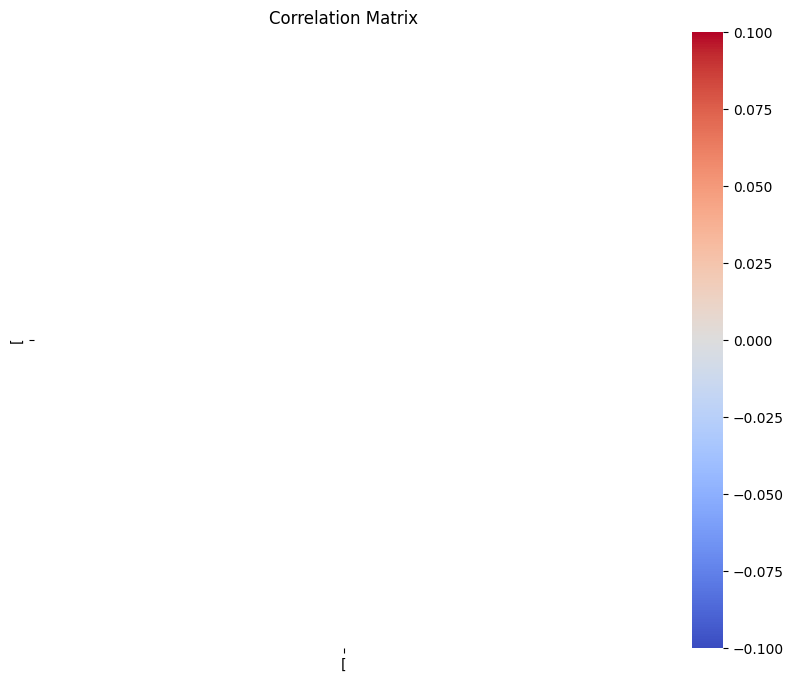

Highly correlated columns: []


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
num_df = df.select_dtypes(include=np.number)

# Correlation matrix
corr_matrix = num_df.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Remove highly correlated columns (threshold = 0.9)
threshold = 0.9
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find columns to drop
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]

print("Highly correlated columns:", to_drop)

# Drop them
df = df.drop(columns=to_drop)

float64


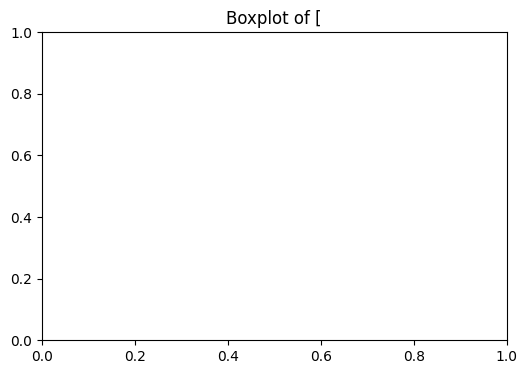

In [ ]:
for col in df.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(6,4))
    print(df[col].dtype)
    plt.title(f"Boxplot of {col}")
    plt.show()

Shape: (45, 1)
Columns: Index(['['], dtype='object')
[    float64
dtype: object
[    45
dtype: int64
[: 0 unique values


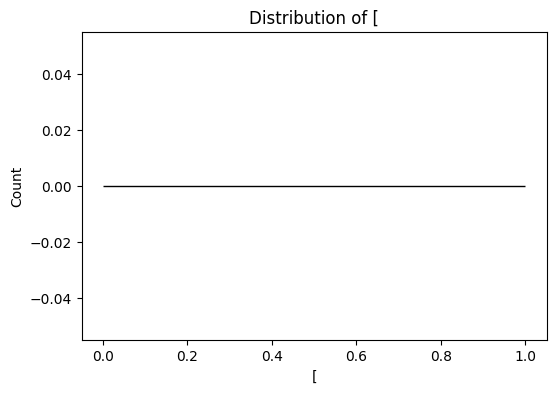

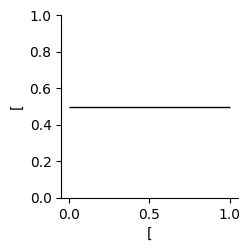

In [ ]:
# 1. Shape of dataset
print("Shape:", df.shape)


print("Columns:", df.columns)


print(df.dtypes)


print(df.isnull().sum())

# 5. Unique values
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

# 6. Value counts (categorical)
for col in df.select_dtypes(include='object').columns:
    print(df[col].value_counts())

# 7. Distribution plots
for col in df.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# 8. Pairplot (optional, for small datasets)
sns.pairplot(df)
plt.show()